In [99]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

In [100]:
df = pd.read_excel("dataset_final_actualizado_FINAL_103filas.xlsx")

In [101]:
df = df.dropna(subset=["categoria"])

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 102
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    98 non-null     object
 1   titulo                98 non-null     object
 2   descripcion           98 non-null     object
 3   categoria             98 non-null     object
 4   subtema               98 non-null     object
 5   palabras_clave        98 non-null     object
 6   fuente                98 non-null     object
 7   url                   96 non-null     object
 8   tipo_fuente           98 non-null     object
 9   descripcion_adaptada  98 non-null     object
 10  fecha_recoleccion     98 non-null     object
dtypes: object(11)
memory usage: 9.2+ KB


In [103]:
frecuencia = df["categoria"].value_counts()
porcentaje = df["categoria"].value_counts(normalize=True) * 100

tabla_frecuencias = pd.DataFrame({
    "Frecuencia": frecuencia,
    "Porcentaje": porcentaje.round(2)
})
tabla_frecuencias

,Frecuencia,Porcentaje
categoria,,
Data Science,20,20.41
Bases de Datos,20,20.41
Backend,20,20.41
Frontend,19,19.39
Cloud/DevOps,19,19.39


In [104]:
tabla_distribucion_estilizada = (
    tabla_frecuencias.style
                     .format({"Porcentaje": "{:.1f}%"})
                     .bar(subset=["Frecuencia"], color="#B7A7E3")
                     .background_gradient(subset=["Porcentaje"], cmap="Purples")
                     .set_caption("Distribución de contenidos por categoría")
)
tabla_distribucion_estilizada

,Frecuencia,Porcentaje
categoria,,
Data Science,20,20.4%
Bases de Datos,20,20.4%
Backend,20,20.4%
Frontend,19,19.4%
Cloud/DevOps,19,19.4%


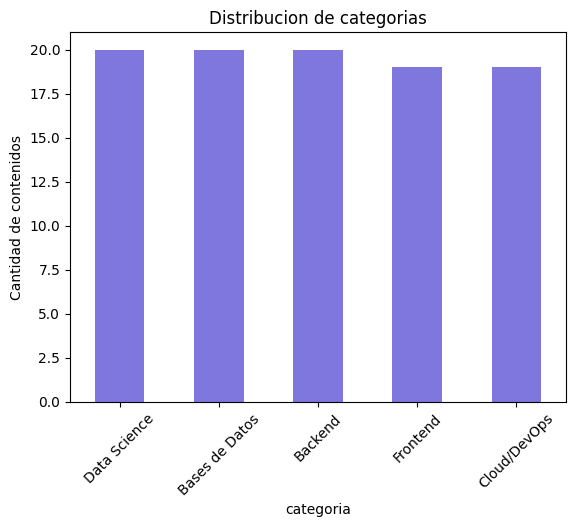

In [105]:
df['categoria'].value_counts().plot(kind='bar', color='#7F77DD')
plt.title("Distribucion de categorias")
plt.ylabel("Cantidad de contenidos")
plt.xticks(rotation=45)
plt.show()

In [106]:
STOPWORDS_ES = {
    "el","la","los","las","de","del","en","un","una","unos","unas","y","o","a",
    "para","por","con","sin","que","como","se","su","sus","es","son","este",
    "esta","estos","estas","al","lo","le","les","mas","muy","entre","sobre",
    "ya","desde","cuando","donde","tambien","antes","despues","usando","uso"
}

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_ES and len(t) > 2]
    return " ".join(tokens)

In [107]:
df["texto_limpio"] = (
    df["titulo"].fillna("") + " " +
    df["descripcion_adaptada"].fillna("")
).apply(limpiar_texto)

df[["titulo", "texto_limpio"]]

,titulo,texto_limpio
0,Pandas: conociendo la biblioteca,pandas conociendo biblioteca importacion exploracion inicial conjuntos datos...
1,Pandas: seleccionar y agrupar datos,pandas seleccionar agrupar datos filtrado seleccion agrupamiento registros d...
2,Pandas: transformacion y manipulacion de datos,pandas transformacion manipulacion datos creacion transformacion columnas tr...
3,Pandas E/S: trabajando con diferentes formatos de archivo,pandas trabajando diferentes formatos archivo carga exportacion datos format...
4,NumPy: analisis numerico eficiente con Python,numpy analisis numerico eficiente python operaciones arrays vectores numeric...
...,...,...
98,Maven: gestione dependencias y haga Build de aplicaciones Java,maven gestione dependencias haga build aplicaciones java gestion dependencia...
99,"Java threads: aprenda a crear, gestionar y aplicar con Spring",java threads aprenda crear gestionar aplicar spring creacion gestion hilos j...
100,"Linux: programas, procesos y paquetes",linux programas procesos paquetes control procesos linux kill top manejo var...
101,Linux: conociendo y utilizando la terminal,linux conociendo utilizando terminal introduccion sistema directorios linux ...


In [108]:
df["longitud_texto"] = df["texto_limpio"].str.len()

df.groupby("categoria")["longitud_texto"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(1)

,count,mean,median,std,min,max
categoria,,,,,,
Backend,20,150.2,151.5,24.8,105,187
Bases de Datos,20,149.0,155.5,34.6,98,216
Cloud/DevOps,19,133.3,129.0,21.6,101,191
Data Science,20,131.7,124.5,27.6,100,181
Frontend,19,142.5,143.0,16.8,110,166


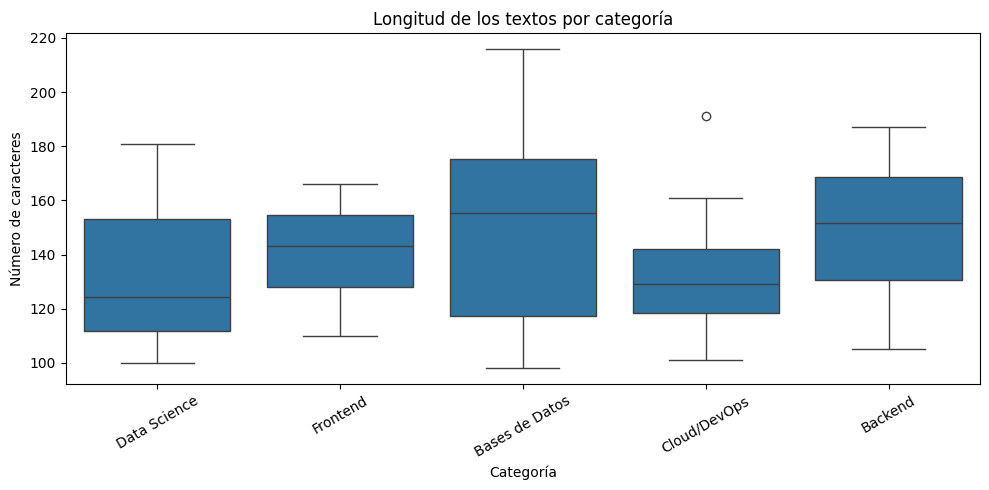

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="categoria", y="longitud_texto", ax=ax)
ax.set_title("Longitud de los textos por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de caracteres")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Separar el texto crudo (limpio, pero SIN vectorizar) en train/test
textos_train, textos_test, y_train, y_test = train_test_split(
    df['texto_limpio'], df['categoria'],
    test_size=0.3, random_state=42, stratify=df['categoria']
)

# 2. El vectorizador se AJUSTA solo con el texto de entrenamiento
vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(textos_train)

# 3. El test solo se TRANSFORMA (usa el vocabulario ya aprendido, no aprende nada nuevo)
X_test = vectorizer.transform(textos_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print()
print(y_train.value_counts())
print()
print(y_test.value_counts())

X_train: (68, 300)
X_test: (30, 300)

categoria
Backend           14
Data Science      14
Bases de Datos    14
Cloud/DevOps      13
Frontend          13
Name: count, dtype: int64

categoria
Data Science      6
Frontend          6
Cloud/DevOps      6
Bases de Datos    6
Backend           6
Name: count, dtype: int64


In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(classification_report(y_test, preds, zero_division=0))

joblib.dump(model, 'modelo_clasificador.joblib')
joblib.dump(vectorizer, 'vectorizer.joblib')

                precision    recall  f1-score   support

       Backend       0.67      1.00      0.80         6
Bases de Datos       0.83      0.83      0.83         6
  Cloud/DevOps       1.00      0.83      0.91         6
  Data Science       1.00      0.83      0.91         6
      Frontend       1.00      0.83      0.91         6

      accuracy                           0.87        30
     macro avg       0.90      0.87      0.87        30
  weighted avg       0.90      0.87      0.87        30



['vectorizer.joblib']

In [112]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_preds)
modelo_accuracy = accuracy_score(y_test, preds)

print(f"Accuracy del modelo base (siempre predice la clase mayoritaria): {dummy_accuracy:.2%}")
print(f"Accuracy de tu LogisticRegression: {modelo_accuracy:.2%}")
print(f"Mejora sobre el modelo base: +{(modelo_accuracy - dummy_accuracy):.2%}")

Accuracy del modelo base (siempre predice la clase mayoritaria): 20.00%
Accuracy de tu LogisticRegression: 86.67%
Mejora sobre el modelo base: +66.67%


In [113]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(max_features=300, ngram_range=(1, 2))),
    ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

resultados = cross_validate(
    pipeline, df["texto_limpio"], df["categoria"], cv=cv, scoring=metricas
)

print("=== Validación cruzada (5 folds) ===")
print(f"Accuracy:        {resultados['test_accuracy'].mean():.2%} ± {resultados['test_accuracy'].std():.2%}")
print(f"Precision macro: {resultados['test_precision_macro'].mean():.2%} ± {resultados['test_precision_macro'].std():.2%}")
print(f"Recall macro:    {resultados['test_recall_macro'].mean():.2%} ± {resultados['test_recall_macro'].std():.2%}")
print(f"F1 macro:        {resultados['test_f1_macro'].mean():.2%} ± {resultados['test_f1_macro'].std():.2%}")
print()
print("Scores individuales por fold (f1_macro):", resultados['test_f1_macro'].round(3))

=== Validación cruzada (5 folds) ===
Accuracy:        90.84% ± 1.96%
Precision macro: 92.67% ± 1.98%
Recall macro:    90.67% ± 2.26%
F1 macro:        90.75% ± 2.15%

Scores individuales por fold (f1_macro): [0.9   0.898 0.903 0.887 0.949]


In [114]:
comparacion = []

dummy_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=300)),
    ("modelo", DummyClassifier(strategy="most_frequent"))
])
resultados_dummy_cv = cross_validate(
    dummy_pipeline, df["texto_limpio"], df["categoria"], cv=cv, scoring="f1_macro"
)

comparacion.append({
    "modelo": "Dummy (clase mayoritaria)",
    "f1_macro_media": resultados_dummy_cv["test_score"].mean(),
    "f1_macro_std": resultados_dummy_cv["test_score"].std()
})
comparacion.append({
    "modelo": "LogisticRegression",
    "f1_macro_media": resultados["test_f1_macro"].mean(),
    "f1_macro_std": resultados["test_f1_macro"].std()
})

tabla_comparacion = pd.DataFrame(comparacion)
tabla_comparacion["f1_macro_media"] = (tabla_comparacion["f1_macro_media"] * 100).round(2)
tabla_comparacion["f1_macro_std"] = (tabla_comparacion["f1_macro_std"] * 100).round(2)
tabla_comparacion

,modelo,f1_macro_media,f1_macro_std
0,Dummy (clase mayoritaria),6.78,0.14
1,LogisticRegression,90.75,2.15


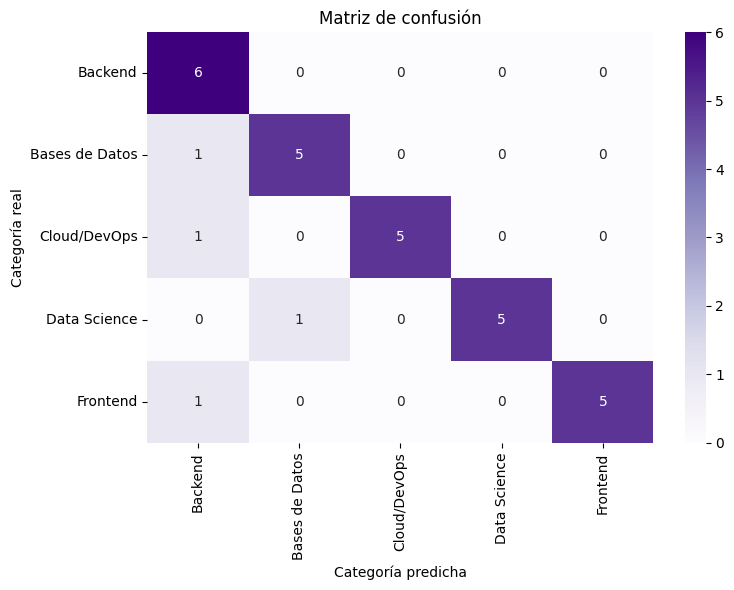

In [115]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
matriz = confusion_matrix(y_test, preds, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Purples",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Matriz de confusión")
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()

In [116]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, preds, labels=labels, zero_division=0
)

metricas = pd.DataFrame({
    "categoria": labels, "precision": precision,
    "recall": recall, "f1": f1, "soporte": support
})

tabla_metricas = (
    metricas.style
            .format({"precision": "{:.1%}", "recall": "{:.1%}", "f1": "{:.1%}"})
            .hide(axis="index")
            .background_gradient(subset=["precision", "recall", "f1"], cmap="Purples")
            .highlight_min(subset=["precision", "recall", "f1"], color="#ffcccc")
            .set_caption("Métricas de clasificación por categoría")
)
tabla_metricas

categoria,precision,recall,f1,soporte
Backend,66.7%,100.0%,80.0%,6
Bases de Datos,83.3%,83.3%,83.3%,6
Cloud/DevOps,100.0%,83.3%,90.9%,6
Data Science,100.0%,83.3%,90.9%,6
Frontend,100.0%,83.3%,90.9%,6


In [117]:
!pip install statsmodels -q
from statsmodels.stats.proportion import proportion_confint
import numpy as np

aciertos = int((preds == y_test).sum())
total = len(y_test)

inferior, superior = proportion_confint(
    count=aciertos, nobs=total, alpha=0.05, method="wilson"
)

print(f"Aciertos: {aciertos} de {total}")
print(f"Accuracy observado: {aciertos/total:.2%}")
print(f"Intervalo de confianza 95% (Wilson): [{inferior:.2%}, {superior:.2%}]")

Aciertos: 26 de 30
Accuracy observado: 86.67%
Intervalo de confianza 95% (Wilson): [70.32%, 94.69%]


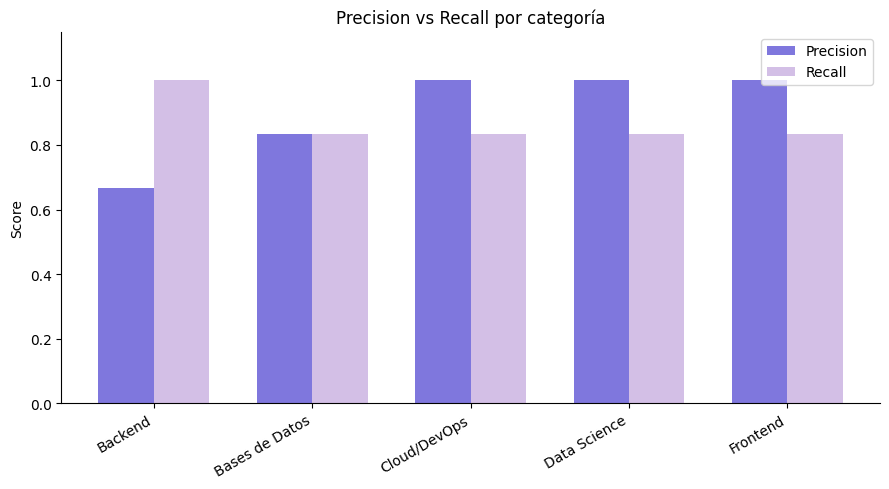

In [118]:
import numpy as np

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, precision, width, label='Precision', color='#7F77DD')
ax.bar(x + width/2, recall, width, label='Recall', color='#D3BFE6')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall por categoría')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()